In [1]:
import shutil
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from parcels import FieldSet, Particle, ParticleFile, ParticleSet, StatusCode
from parcels.kernels import AdvectionEE, AdvectionRK4
from scipy.special import erf

from mechanical_drifters.models.spar_buoy_simple import SparBuoySimple
from mechanical_drifters.parcels import make_kernel

/Users/merlefriederichsen/src/mechanical_drifters/.pixi/envs/default/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/var/folders/kv/m9728dx96_dfgqw5xnsv8njm0000gn/T/ipykernel_75502/2363549170.py:7: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  from parcels import FieldSet, Particle, ParticleFile, ParticleSet, StatusCode


In [2]:
# constant eastern wind
U_Wind = 0.0
V_Wind = 10.0

U_Water_0 = 2.0 # surface current
V_Water_0 = 0.0
Draft = 10.0 # m
Water_Depth = 20.0 # m

NX = 300              # grid x-dimension
NY = 150              # grid y-dimension
NZ = 20               # grid z-dimension
DT = 900.0            # timestep: 5 min [s]
RUNTIME = 3600.0     # total: 24 hours [s]
OUTPUTDT = 900.0      # output every 5 min
OUTPUT_DIR = "output"

In [3]:
x = np.linspace(-200_000, 200_000, NX)
y = np.linspace(-50_000, 50_000, NY)

depth_air = np.linspace(-10.0, 0.0, 11, endpoint = False)
depth_water = np.linspace(0.0, 100.0, NZ)

depth = np.unique(np.concatenate([depth_air, depth_water]))

#depth = np.linspace(-10, 100, NZ)

time = np.array([0.0])

In [4]:
Z, Y, X = np.meshgrid(depth, y, x, indexing = "ij")

In [5]:
zz = np.clip(Z / Draft, 0.0, 1.0)

In [6]:
# Fallunterscheidung z < 0, > 0
U_water = U_Water_0 * 0.5 * (1 + np.cos(np.pi * zz))
V_water = V_Water_0 * 0.5 * (1 + np.cos(np.pi * zz))

U_Profile = np.where(Z < 0, U_Wind, U_water)
V_Profile = np.where(Z < 0, V_Wind, V_water)

U_data = U_Profile[None, ...]
V_data = V_Profile[None, ...]

U_data = np.zeros(((len(time), len(depth), len(y), len(x))))
V_data = np.full(((len(time), len(depth), len(y), len(x))), 0.5)

In [7]:
# Build xarray Dataset with SGRID metadata
ds = xr.Dataset(
    {
        "U": (["time", "depth", "y", "x"], U_data),
        "V": (["time", "depth", "y", "x"], V_data),
        "grid": xr.DataArray(
            data=0,
            attrs={
                "cf_role": "grid_topology",
                "topology_dimension": 2,
                "node_dimensions": "x y",
                "face_dimensions": "x:x (padding: none) y:y (padding: none)",
                "vertical_dimensions": "depth:depth (padding: none)",
                "node_coordinates": "x y",
            },
        ),
    },
    coords={
        "x": ("x", x, {"axis": "X"}),
        "y": ("y", y, {"axis": "Y"}),
        "depth": ("depth", depth, {"axis": "Z"}),
        "time": ("time", time, {"axis": "T"}),
    },
)

fieldset = FieldSet.from_sgrid_conventions(ds, mesh="flat")

In [8]:
spar = SparBuoySimple(backend = "numba")
spar_kernel = make_kernel(spar)

def DeleteOOB(particles, fieldset):
    """Convert out-of-bounds errors to Delete status."""
    state = np.asarray(particles.state)
    oob = (state == StatusCode.ErrorOutOfBounds) | (state == StatusCode.ErrorThroughSurface)
    if np.any(oob):
        particles.state = np.where(oob, StatusCode.Delete, state)

In [9]:
output_dir = Path("output_spar_buoy")
output_dir.mkdir(parents=True, exist_ok=True)

In [10]:
release_x = [1000.0, 2000.0, 3000.0, 4000.0]
release_y = [0.0, 1000.0, 2000.0, 3000.0]
n_particles = len(release_x)

spar_store = str(output_dir / "01_spar_buoy.zarr")
shutil.rmtree(spar_store, ignore_errors=True)

In [11]:
pset_spar = ParticleSet(
    fieldset=fieldset,
    pclass=Particle,
    lon=release_x,
    lat=release_y,
    z=[0] * n_particles,
)

In [12]:
print("U min/max:", np.nanmin(U_data), np.nanmax(U_data))
print("V min/max:", np.nanmin(V_data), np.nanmax(V_data))

U min/max: 0.0 2.0
V min/max: 0.0 10.0


In [13]:
pset_spar.execute(
    kernels=[spar_kernel, DeleteOOB],
    dt=DT,
    runtime=RUNTIME,
    output_file=ParticleFile(store=spar_store, outputdt=OUTPUTDT),
    verbose_progress=False,
)

INFO: Output files are stored in /Users/merlefriederichsen/src/mechanical_drifters/examples/spar_buoy/output_spar_buoy/01_spar_buoy.zarr


/Users/merlefriederichsen/src/mechanical_drifters/.pixi/envs/default/lib/python3.14/site-packages/parcels/_core/particlefile.py:281: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  np.less_equal(
/Users/merlefriederichsen/src/mechanical_drifters/.pixi/envs/default/lib/python3.14/site-packages/parcels/_core/particlefile.py:286: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.greater_equal(
/Users/merlefriederichsen/src/mechanical_drifters/.pixi/envs/default/lib/python3.14/site-packages/parcels/_core/particlefile.py:293: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  & np.equal(time, particle_data["time"], where=np.isfinite(particle_data["time"]))


In [14]:
ds_spar = xr.open_zarr(spar_store)
ds_spar

/var/folders/kv/m9728dx96_dfgqw5xnsv8njm0000gn/T/ipykernel_75502/84997035.py:1: FutureWarning: In a future version, xarray will not decode the variable 'time' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds_spar = xr.open_zarr(spar_store)


<xarray.Dataset> Size: 452B
Dimensions:     (trajectory: 4, obs: 5)
Coordinates:
  * trajectory  (trajectory) int64 32B 0 1 2 3
  * obs         (obs) int32 20B 0 1 2 3 4
Data variables:
    lat         (trajectory, obs) float32 80B dask.array<chunksize=(4, 1), meta=np.ndarray>
    lon         (trajectory, obs) float32 80B dask.array<chunksize=(4, 1), meta=np.ndarray>
    time        (trajectory, obs) timedelta64[ns] 160B dask.array<chunksize=(4, 1), meta=np.ndarray>
    z           (trajectory, obs) float32 80B dask.array<chunksize=(4, 1), meta=np.ndarray>
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_grid_mesh:      flat
    parcels_kernels:        _kernelDeleteOOB
    parcels_version:        3.1.3.dev2018

/var/folders/kv/m9728dx96_dfgqw5xnsv8njm0000gn/T/ipykernel_75502/4188339298.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


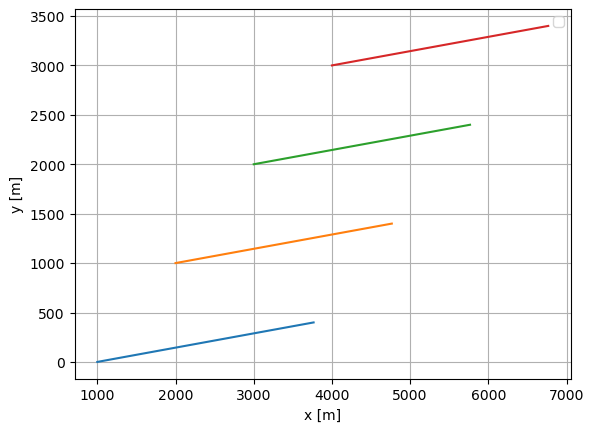

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

for i in range(ds_spar.sizes["trajectory"]):
    ax.plot(
        ds_spar.lon.isel(trajectory = i),
        ds_spar.lat.isel(trajectory = i),
    )

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.legend()
ax.grid(True)
plt.show()